## 정규분포,

### 밀도, 확률, 분포표
관련 분포: $ t, \chi^2, F $

In [16]:
# 정규분포표 표 작성
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats   # 이렇게 하면 stats.norm(어쩌구)
from scipy.stats import norm  # 이렇게 하면 norm(어쩌구...


$ X \sim N(\mu, \sigma^2 ) $, 이때 $ X $의 밀도 at $ x $.
 $$ f(x) = {1 \over \sqrt{2 \pi \sigma^2} } e^{ -{1 \over 2\sigma^2} (x - \mu)^2 } $$

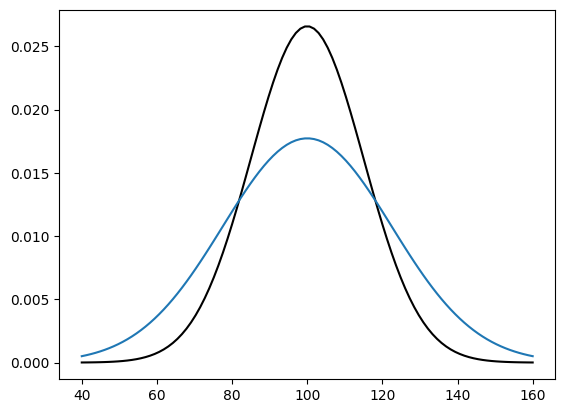

In [17]:
# 정규분포의 pdf 생성

# * **다양한 확률분포 기반 난수 생성 (`np.random` / `scipy.stats`):**
# * **정규분포:** `np.random.normal(loc=평균, scale=표준편차, size=크기)`
# * **균일분포:** `np.random.uniform(low=최솟값, high=최댓값, size=크기)`
# * **이항분포:** `np.random.binomial(n=시도횟수, p=확률, size=크기)`
# * **포아송분포:** `np.random.poisson(lam=평균발생횟수, size=크기)`
# t, chisquare, F.

mu, sig = 100, 15
x = np.linspace(mu-4*sig, mu+4*sig, 100)
y = norm.pdf(x, loc=mu, scale=sig)
p = norm.cdf(x, loc=mu, scale=sig)
plt.plot(x, y, color='black')   # density

# 정규분포의 pdf 함수 f(x) 정의.
def norm_density(x, mu, sig ) :
    y = ( 1 / np.sqrt(2 * np.pi * sig**2 )) * np.exp( - 1 / ( 2 * sig**2 ) * (x - mu)**2 )
    return y

z = norm_density(x, mu, sig*1.5)  # 위에서 정의한 함수 호출
plt.plot(x, z)


### 표준정규분포표 생성
$$ P( Z < z ) = \int_{-\infty}^z f(u) du $$
$ x $가 0보다 큰 쪽만 계산

In [18]:
import os
# standard normal table
x = np.linspace(0, 3, 301)
p = norm.cdf(x, 0, 1)
# print(x, p)

# 1. z값 범위 설정 (행: 0.0 ~ 3.9, 열: 0.00 ~ 0.09)
row_z = np.arange(0.0, 4.0, 0.1)      # 소수점 첫째 자리까지
col_z = np.arange(0.00, 0.10, 0.01)   # 소수점 둘째 자리

# 2. 누적확률(CDF) 계산을 위한 빈 데이터프레임 틀 생성
z_table = pd.DataFrame(index=np.round(row_z, 1), columns=[f'{c:.2f}' for c in col_z])
# z_table.info()


# 3. 각 (행 + 열) z값에 대한 누적확률 P(Z <= z) 계산 (scipy.stats.norm.cdf 활용)
for r in row_z:
    for c in col_z:
        z_val = r + c
        # norm.cdf: 표준정규분포의 누적확률 분포 함수
        prob = norm.cdf(z_val)

        # 행/열 인덱스 매핑하여 소수점 4자리까지 표시
        z_table.loc[round(r, 1), f'{c:.2f}'] = f'{prob:.4f}'

# 데이터프레임 이름 설정
z_table.index.name = 'z'

# 4. 결과 출력
z_table.head(7)  # 위 15개 행 출력
# z_table.to_csv('o_files/z_table.csv')
# z_table.to_excel('o_files/z_table.xlsx')


,0.00,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09
z,,,,,,,,,,
0.0,0.5000,0.5040,0.5080,0.5120,0.5160,0.5199,0.5239,0.5279,0.5319,0.5359
0.1,0.5398,0.5438,0.5478,0.5517,0.5557,0.5596,0.5636,0.5675,0.5714,0.5753
0.2,0.5793,0.5832,0.5871,0.5910,0.5948,0.5987,0.6026,0.6064,0.6103,0.6141
0.3,0.6179,0.6217,0.6255,0.6293,0.6331,0.6368,0.6406,0.6443,0.6480,0.6517
0.4,0.6554,0.6591,0.6628,0.6664,0.6700,0.6736,0.6772,0.6808,0.6844,0.6879
0.5,0.6915,0.6950,0.6985,0.7019,0.7054,0.7088,0.7123,0.7157,0.7190,0.7224
0.6,0.7257,0.7291,0.7324,0.7357,0.7389,0.7422,0.7454,0.7486,0.7517,0.7549


## 정규분포의 누적확률, 유의수준에 대응되는 경계값 계산


In [21]:
# 1. x까지 누적확률
x = 1.7
p = norm.cdf(x, 0, 1)
print(f'P(Z <= {x}) = {p:.4f}')

alpha = 0.05
z_lft = norm.ppf(alpha/2, 0, 1)
z_rgt = norm.ppf(1 - alpha/2, 0, 1)
print(f'P(Z <= {z_lft}) = {alpha/2:.4f}')
print(f'P(Z <= {z_rgt}) = {1 - alpha/2:.4f}')


P(Z <= 1.7) = 0.9554
P(Z <= -1.9599639845400545) = 0.0250
P(Z <= 1.959963984540054) = 0.9750


## other distributions, $ t_{df} $
\begin{align}
 T &= { Z \over \sqrt{ K/df } }  \\
   &\sim t_{df}
\end{align}
$ Z\sim N(0,1) , \ K \sim \chi_{df}^2 $

In [ ]:
from matplotlib.lines import lineStyles

from scipy.stats import t, chi2, f
# 예시 데이터 (X축 범위)
x = np.linspace(-5, 5, 500)

# t-분포 (자유도 10인 경우)
dof = 5
y_t = t.pdf(x, df= dof, loc=0, scale=1)
y = norm.pdf(x, loc= 0, scale= 1)

plt.figure(figsize=(7, 5))
plt.plot(x, y , linestyle='--', lw=0.51, color='black')   # density
plt.plot(x, y_t)   # density
plt.title(" $ t $, $ Z $ ")


## other distributions, $ K, F $
\begin{align}
K & = Z_1^2 + Z_2^2 + \cdots + Z_H^2 \\
  & \sim \chi_H^2  \\
F & = { K_1 /df_1 \over K_2 /df_2 } \\
 & \sim F_{( df_1, df_2 )}
\end{align}
$ Z_i, Z_j $ 서로 독립 $ \forall i, j $.
$ K_1, K_2 $ 서로 독립.


In [ ]:

from scipy.stats import t, chi2, f

x_pos = np.linspace(0, 5, 500) # 카이제곱과 F분포는 양수 영역만 존재하므로 별도 지정
# 카이제곱 분포 (자유도 4인 경우)
y_c = chi2.pdf(x_pos, df=3)
# F-분포 (분자 자유도 5, 분모 자유도 15인 경우)
y_f = f.pdf(x_pos, dfn=5, dfd=15)

plt.figure(figsize=(8, 6))
plt.plot(x_pos, y_c )   # density
plt.plot(x_pos, y_f)   # density
plt.title(" $ \\chi^2 , F $ ")
